<a href="https://colab.research.google.com/github/Anuska111/Customer_Churn_Prevention_/blob/main/Customer_Churn_Prevention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn.csv to customer_churn (4).csv


In [3]:
df = pd.read_csv("customer_churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:

# Basic Information
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Shape: (7043, 33)

Data Types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: objec

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


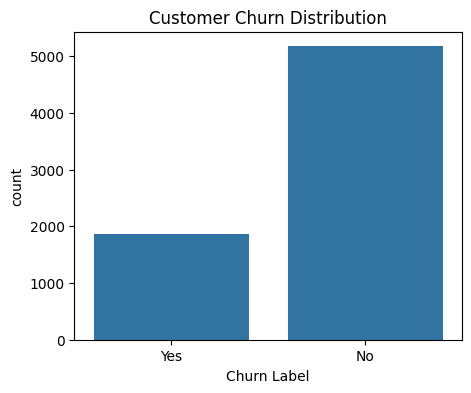

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

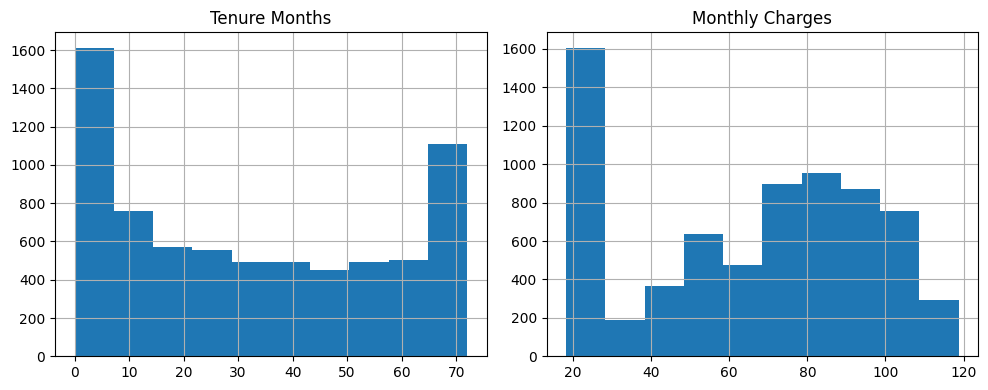

In [7]:
df[["Tenure Months","Monthly Charges","Total Charges"]].hist(figsize=(10,4))
plt.tight_layout()
plt.show()

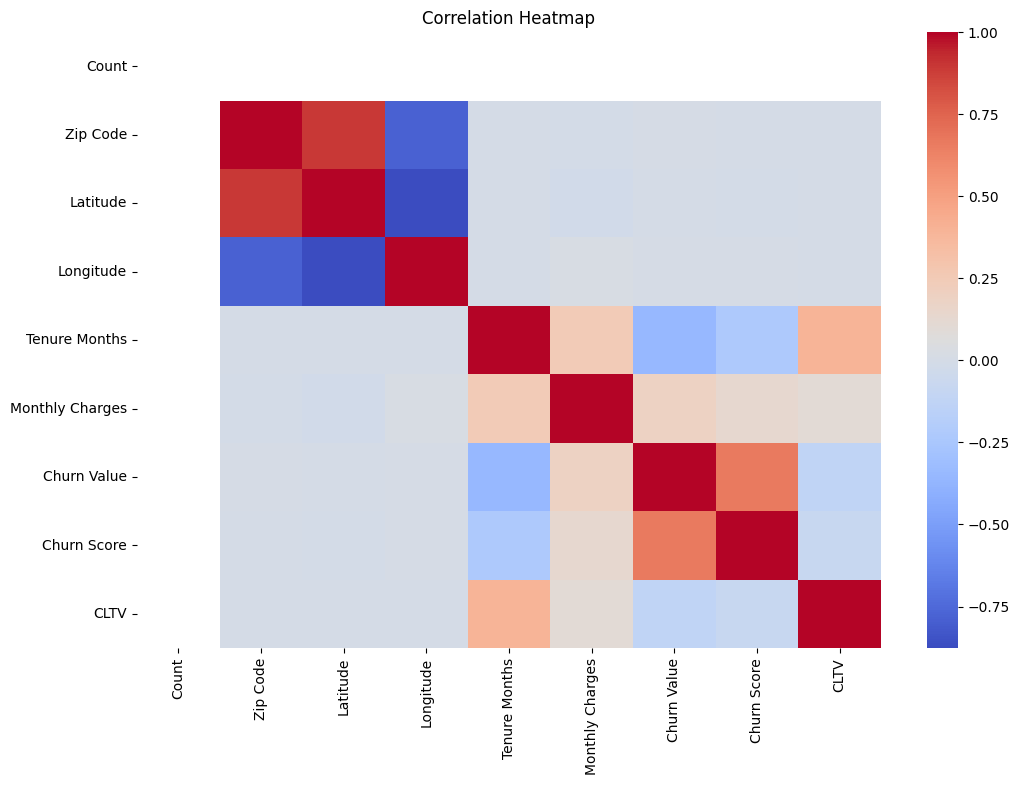

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [10]:
X = df.drop(["Churn Value", "Churn Label", "Churn Score", "Churn Reason"], axis=1)
y = df["Churn Value"]

In [11]:
df = df.drop([
    "CustomerID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Score",
    "CLTV",
    "Churn Reason"
], axis=1)

In [12]:
print(df.columns)

Index(['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value'],
      dtype='object')


In [13]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [14]:
print(X.shape)
print(y.shape)

(7043, 21)
(7043,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 21)
(1409, 21)


In [16]:
print(X.columns.tolist())

['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']


In [17]:
X = df.drop(["Churn Value", "Churn Label"], axis=1)
y = df["Churn Value"]

print(X.columns.tolist())

['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [18]:
X = df.drop(["Churn Value", "Churn Label"], axis=1)
y = df["Churn Value"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Re-define Numerical and Categorical columns based on the current X
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Re-initialize Preprocessing steps
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Re-create the pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])
# Define param_grid (it was missing after the previous cell was deleted)
param_grid = {
    "classifier__n_estimators": [200, 250],
    "classifier__max_depth": [20, 25],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__class_weight": [
        "balanced",
        {0: 1, 1: 1.25},
        {0: 1, 1: 1.5},
        {0: 1, 1: 1.75}
    ]
}
# Re-initialize GridSearchCV with the new pipeline
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Re-fit the model with the corrected X_train
grid_search.fit(X_train, y_train)

print("Best Parameters (after re-fit):", grid_search.best_params_)
print("Best CV F1 (after re-fit):", grid_search.best_score_)

Best Parameters (after re-fit): {'classifier__class_weight': 'balanced', 'classifier__max_depth': 25, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 250}
Best CV F1 (after re-fit): 0.6442638237599065


In [45]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7629524485450674
Precision: 0.5390625
Recall   : 0.7379679144385026
F1 Score : 0.6230248306997742


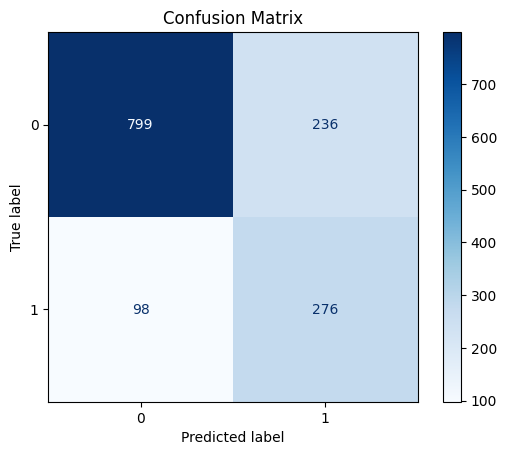

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [48]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8367278927381228


In [49]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.20, 0.81, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    temp_pred = (y_prob >= threshold).astype(int)
    temp_f1 = f1_score(y_test, temp_pred)

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Threshold F1:", best_f1)

Best Threshold: 0.5000000000000002
Best Threshold F1: 0.6230248306997742


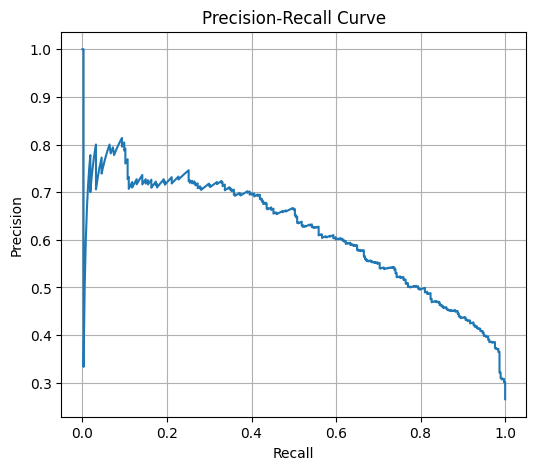

In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

In [41]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


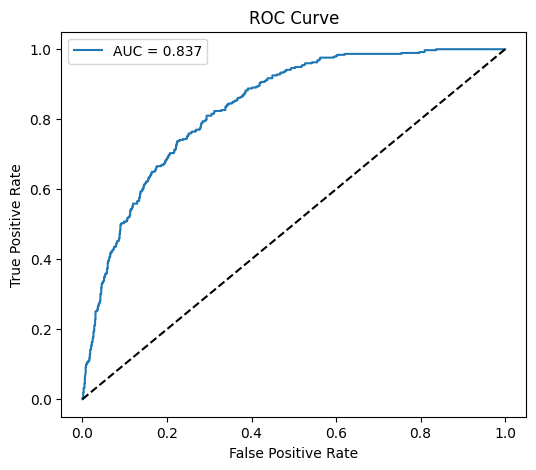

ROC-AUC Score: 0.8367278927381228


In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc)

In [43]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl")

print("✅ customer_churn_model.pkl saved successfully")

✅ customer_churn_model.pkl saved successfully


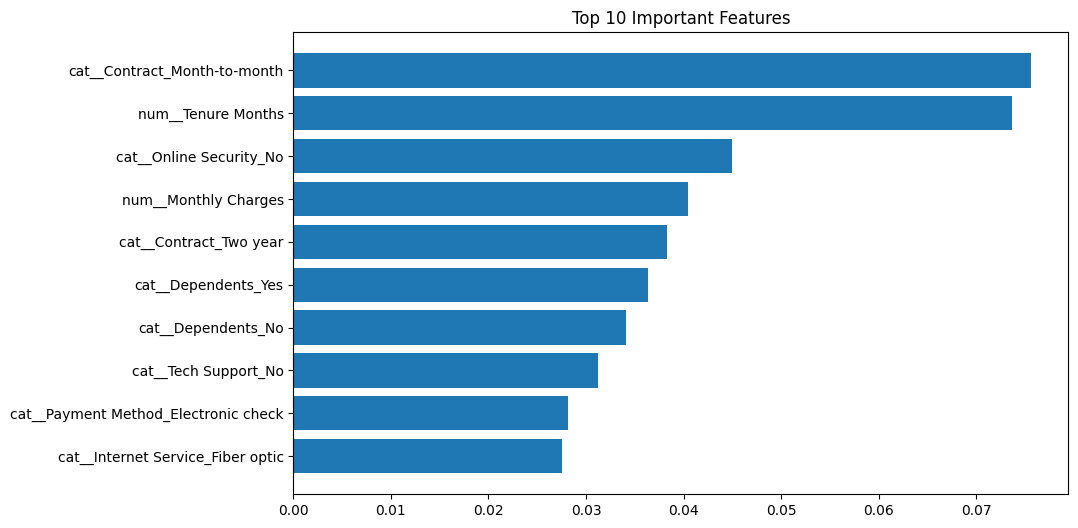

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [33]:
!pip install streamlit

In [56]:
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Customer Churn Prediction", page_icon="📊")

# Load model
model = joblib.load("customer_churn_model.pkl")

st.title("📊 Customer Churn Prediction")
st.write("Enter customer details to predict churn risk.")

# Inputs
gender = st.selectbox("Gender", ["Male", "Female"])
senior = st.selectbox("Senior Citizen", [0, 1])
partner = st.selectbox("Partner", ["Yes", "No"])
dependents = st.selectbox("Dependents", ["Yes", "No"])
tenure = st.number_input("Tenure Months", 0, 100, 12)
phone = st.selectbox("Phone Service", ["Yes", "No"])
multiple = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
device = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
tech = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
paperless = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)
monthly = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
total = st.number_input("Total Charges", min_value=0.0, value=1000.0)

# Prediction
if st.button("Predict Churn"):

    data = pd.DataFrame({
        "Gender": [gender],
        "Senior Citizen": [senior],
        "Partner": [partner],
        "Dependents": [dependents],
        "Tenure Months": [tenure],
        "Phone Service": [phone],
        "Multiple Lines": [multiple],
        "Internet Service": [internet],
        "Online Security": [security],
        "Online Backup": [backup],
        "Device Protection": [device],
        "Tech Support": [tech],
        "Streaming TV": [tv],
        "Streaming Movies": [movies],
        "Contract": [contract],
        "Paperless Billing": [paperless],
        "Payment Method": [payment],
        "Monthly Charges": [monthly],
        "Total Charges": [total]
    })

    prediction = model.predict(data)[0]
    probability = model.predict_proba(data)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk of Churn\n\nProbability: {probability:.2%}")
    else:
        st.success(f"✅ Low Risk of Churn\n\nProbability: {probability:.2%}")

2026-07-30 05:35:29.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 05:35:29.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [60]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [62]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Customer Churn Prediction", page_icon="📊")

# Load model
model = joblib.load("customer_churn_model.pkl")

st.title("📊 Customer Churn Prediction")
st.write("Enter customer details to predict churn risk.")

# Inputs
gender = st.selectbox("Gender", ["Male", "Female"])
senior = st.selectbox("Senior Citizen", [0, 1])
partner = st.selectbox("Partner", ["Yes", "No"])
dependents = st.selectbox("Dependents", ["Yes", "No"])
tenure = st.number_input("Tenure Months", 0, 100, 12)
phone = st.selectbox("Phone Service", ["Yes", "No"])
multiple = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
device = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
tech = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
paperless = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)
monthly = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
total = st.number_input("Total Charges", min_value=0.0, value=1000.0)

# Prediction
if st.button("Predict Churn"):

    data = pd.DataFrame({
        "Gender": [gender],
        "Senior Citizen": [senior],
        "Partner": [partner],
        "Dependents": [dependents],
        "Tenure Months": [tenure],
        "Phone Service": [phone],
        "Multiple Lines": [multiple],
        "Internet Service": [internet],
        "Online Security": [security],
        "Online Backup": [backup],
        "Device Protection": [device],
        "Tech Support": [tech],
        "Streaming TV": [tv],
        "Streaming Movies": [movies],
        "Contract": [contract],
        "Paperless Billing": [paperless],
        "Payment Method": [payment],
        "Monthly Charges": [monthly],
        "Total Charges": [total]
    })

    prediction = model.predict(data)[0]
    probability = model.predict_proba(data)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk of Churn\n\nProbability: {probability:.2%}")
    else:
        st.success(f"✅ Low Risk of Churn\n\nProbability: {probability:.2%}")

Writing app.py


In [57]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
streamlit

Overwriting requirements.txt


In [63]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl", compress=3)

print("✅ Model saved with compression")

✅ Model saved with compression
